
Geo Data Science with Python,
Prof. Susanna Werth, VT Geosciences

# Unsupervised Machine Learning 


This notebook is accompanied by the lecture L10 presentation slides.


---


Content:
-------

- **A.** Principle Component Analysis (PCA) via Singluar Value Decomposition (SVD) 
- **B.** Clustering from Scratch
- **C.** PCA and Clustering of Sea Surface Temperature Data

--- 

In [1]:

# On Google Colab, install the following packages...

# ! pip install netcdf4


In [2]:

# Import standard packages
import requests
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd

# let's set a standard size for figures (a bit smaller, so they fit on the screen)
from matplotlib import rcParams
rcParams['figure.figsize'] = [4, 3]
rcParams.update({'font.size': 10})


In [3]:
# Download data

# Download Dog image
url = ('https://raw.githubusercontent.com/GeoPythonVT/geosf25_material/main/data/svd_material/dog.jpg')
out = "dog.jpg"
r = requests.get(url)
open(out, "wb").write(r.content)

# Download series of dog & cat images
url = ('https://raw.githubusercontent.com/GeoPythonVT/geosf25_material/main/data/svd_material/catdata.csv')
out = "catdata.csv"
r = requests.get(url)
open(out, "wb").write(r.content)
url = ('https://raw.githubusercontent.com/GeoPythonVT/geosf25_material/main/data/svd_material/dogdata.csv')
out = "dogdata.csv"
r = requests.get(url)
open(out, "wb").write(r.content)

# Download TOS data
url = ('https://raw.githubusercontent.com/GeoPythonVT/geosf25_material/main/data/svd_material/tos_O1_2001-2002.nc')
out = "tos_O1_2001-2002.nc"
r = requests.get(url)
open(out, "wb").write(r.content)

2949152

---
# A. Principle Component Analysis

Principal Component Analysis (PCA) is a technique that identifies the main directions of variance in data by applying Singular Value Decomposition (SVD) to transform the original variables into a new set of orthogonal components, ordered by the amount of variance they explain.


## Example 1: A Single Dog Image


First, let's look at an example dog image:

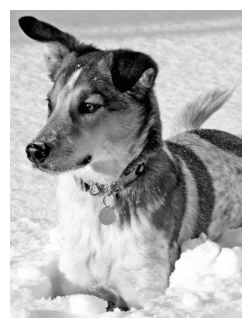

In [4]:
from matplotlib.image import imread
import os

plt.rcParams['figure.figsize'] = [8, 4]

A = imread(os.path.join('.','dog.jpg'))
X = np.mean(A, -1); # Convert RGB to grayscale

img = plt.imshow(X)
img.set_cmap('gray')
plt.axis('off')
plt.show()

Now we will perform a singular value decomposition of the dog image using the numpy `linalg` package:

In [5]:

# SVD
U, S, VT = np.linalg.svd(X,full_matrices=False)
U.shape, S.shape,VT.shape

((2000, 1500), (1500,), (1500, 1500))

What can we do with that?:
1. Image compression: keep only the top singular values
2. Image denoising: remove small singular values
3. Approximate the image: low-rank reconstruction
4. Extract dominant spatial features inside that one image

To understand the options, let's reconstruct the image with only some of the loadings (singular values):

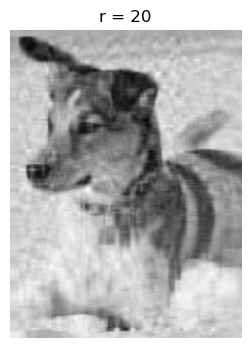

In [6]:

r = 20  # change to 1 to see first mode
S = np.diag(S) # transform into full sigma matrix
Xapprox = U[:,:r] @ S[0:r,:r] @ VT[:r,:] # reconstruction

plt.figure()
img = plt.imshow(Xapprox)
img.set_cmap('gray')
plt.axis('off')
plt.title('r = ' + str(r))
plt.show()

These 20 loadings seem not enough to receive a sharp image. However, we also don't need all 1000, so let's try 50 and 100:

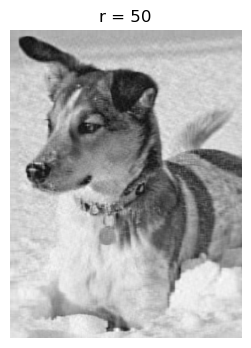

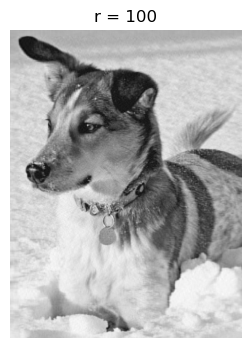

In [7]:
plt.rcParams['figure.figsize'] = [8, 4]

j = 0
for r in (50, 100):
    # Construct approximate image
    Xapprox = U[:,:r] @ S[0:r,:r] @ VT[:r,:]
    plt.figure(j+1)
    j += 1
    img = plt.imshow(Xapprox)
    img.set_cmap('gray')
    plt.axis('off')
    plt.title('r = ' + str(r))
    plt.show()

Now let's look at the singular values which reflect the **energy distribution of the signal**.

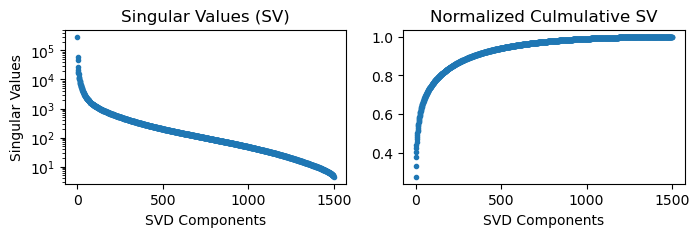

In [8]:

# Singular values
fig, ax = plt.subplots(1,2,figsize=[8,2])
ax[0].semilogy(np.diag(S),'.')
ax[0].set_title('Singular Values (SV)'), ax[1].set_title('Normalized Culmulative SV')
ax[0].set_xlabel('SVD Components'), ax[1].set_xlabel('SVD Components')
ax[0].set_ylabel('Singular Values')
ax[1].plot(np.cumsum(np.diag(S))/np.sum(np.diag(S)),'.')
plt.show()


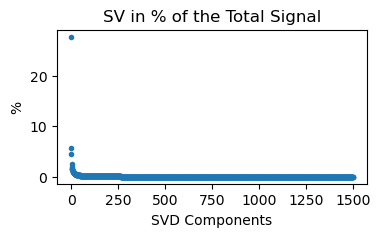

In [9]:

Svals = np.diag(S)

# Plot Singular values in percentage of the signal
plt.subplots(figsize=[4,2])
plt.plot(Svals/np.sum(Svals)*100,'.')
plt.ylabel('%'), plt.xlabel('SVD Components')
plt.title('SV in % of the Total Signal')
plt.show()

**Task**: Discuss the graphs. What do they show?

## Example 2: Feature Engineering with many Dog & Cat Images

What happens?

You create a data matrix:
- Each row = one image (flattened)
- Each column = pixel position

PCA now finds:

- Modes of variation across all dogs and cats
- Eigen-dogs/cats or principal dog/cat features
- Latent structure of the dog image dataset


In [10]:
from matplotlib import rcParams
#from scipy import io
#import os
from mpl_toolkits.mplot3d import Axes3D

# read data from csv file
dog = np.genfromtxt('./dogdata.csv',delimiter=',')
cat = np.genfromtxt('./catdata.csv',delimiter=',')


In [11]:
cat.shape

(4096, 80)

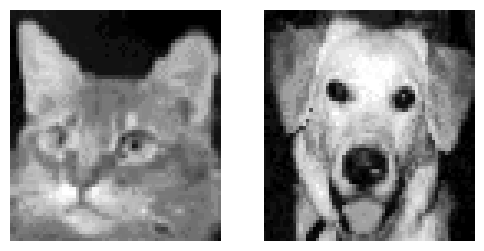

In [12]:
# plot a single cat and dog to see they are actually such images

catNumber = 1 # max 80
dogNumber = 5 # max 80

cat_plot = np.rot90(np.reshape(cat[:,catNumber],(64,64)))
dog_plot = np.rot90(np.reshape(dog[:,dogNumber],(64,64)))

fig,axs = plt.subplots(1,2, figsize=(6,3)) 
axs[0].pcolor(cat_plot,cmap='gray'), axs[0].axis('off')
axs[1].pcolor(dog_plot,cmap='gray'), axs[1].axis('off')
plt.show()


Next, let's combine all the cat and dog images and store them as vectors in a big data matrix X and then calculate the SVD over all images (each image being one variable/measurement).

In [13]:

# combine data in one matrix and run SVD
X_CD = np.concatenate((dog,cat),axis=1)

# Estimate SVD
u,s,vT = np.linalg.svd(X_CD-np.mean(X_CD),full_matrices=0) # note we are not asking for the full matrix!


In [14]:
X_CD.shape

(4096, 160)

In [15]:
u.shape, s.shape

((4096, 160), (160,))

Let's look at the first few features in the decomposition

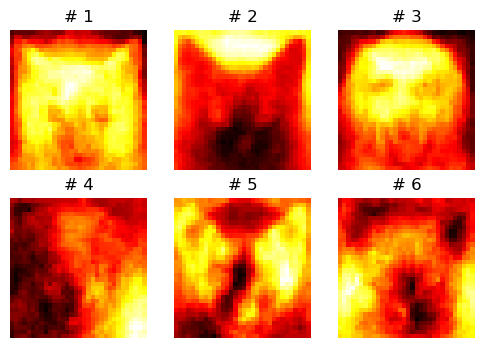

In [16]:

# Plotting main features in the columns (scores: U-matrix) of the SVD
# Note: the trickiest part here is reshaping the column vectors back to images

fig,axs = plt.subplots(2,3, figsize=(6,4))
axs = axs.reshape(-1)
for j in range(6):
    U = np.flipud(np.reshape(u[:,j],(64,64)))
    U2 = U[::2,::2]
    axs[j].pcolor(np.rot90(U2),cmap='hot')
    axs[j].axis('off')
    axs[j].set_title('# '+str(j+1))
    

We can also retrieve a **histogram** of the **loadings** (columns of the V matrix, Eigenvectors, **importance of each freature above for every single image**) and split them up by cats and dogs (first and last 80 columns).

In [17]:
np.max(vT)

np.float64(0.5593522185809203)

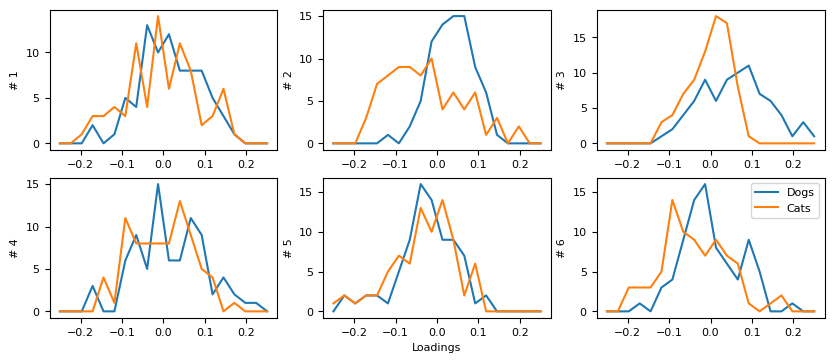

In [18]:
# bins for histogram
xbin = np.linspace(-0.25,0.25,20)
xbin_edges = np.append(xbin,xbin[-1]+(xbin[1]-xbin[0])) - (xbin[1]-xbin[0])/2

plt.rcParams['figure.figsize'] = [10, 4]
plt.rcParams.update({'font.size': 8})
fig,axs = plt.subplots(2,3)
axs = axs.reshape(-1)
for j in range(6):
    pdf1 = np.histogram(vT[j,:80],bins=xbin_edges)[0]
    pdf2 = np.histogram(vT[j,80:],bins=xbin_edges)[0]
    axs[j].plot(xbin,pdf1,label='Dogs')
    axs[j].plot(xbin,pdf2,label='Cats')
    axs[j].set_ylabel('# '+str(j+1))

axs[j-1].set_xlabel("Loadings")
axs[j].legend(loc='upper right')

Lastly, let's also plot the singular values in culmulative sum and in percentage of the total signal:

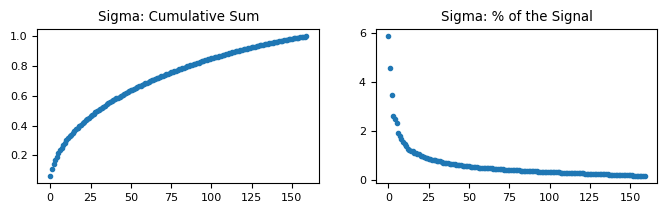

In [19]:

# Plot Singular values
fig, ax = plt.subplots(1,2,figsize=[8,2])

ax[0].plot(np.cumsum(s)/np.sum(s),'.')
ax[0].set_title('Sigma: Cumulative Sum')

ax[1].plot(s/np.sum(s)*100,'.')
ax[1].set_title('Sigma: % of the Signal')

plt.show()

**What can you do with this kind of PCA/SVD?**

- Identify features that distinguish the two groups (eigen-dogs vs eigen-cats).
- When further analysing the features:
    1. Find the dominant modes of variation across all images (e.g., differences in shape, texture, ears, overall silhouette).
    2. Study how variability differs between classes (e.g., cats vary more in pose, dogs vary more in size).
- Detect outliers (e.g., mislabeled animals, unusual poses, rare breeds).
- Denoising by projecting them onto the main components.
- Image compression of an entire dataset


SVD/PCA is a useful and common pre-processing algorithm for other machine learning approaches, e.g.:

- Supervised ML example: Separate dogs and cats in PCA space (clustering of the scores).
- Unsupervised ML example: Use components as features for classification (input to prediction models).


---
# Exercise A.

1. Inspect the feature images and loading histograms as well as the application examples above. Then discuss: Which of the features looks more like cats and which more like dogs? Do you think we could use these features to build a classification model automatically identifying cat and dog images?

2. Review the code and identfy the use of U, S and VT for the example with many cats and dog images. Then, define the PCA loadings (W matrix), scores (T matrix) and eigenvalues (lambda) from the SVD results. Plot and discuss, how the PCA eigenvalues compare to the SVD singular values.


---
# B. Clustering


First, we import the necessary packages, including SciPy and scikit-learn functions.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({'font.size': 10})
plt.rcParams['figure.figsize'] = [4, 3]

## Synthetic Dataset for Clustering

Now, let's generate a random dataset of two clusters, on which we can experiment later with clustering algorithms. We start with a random point cloude (ellipse) centered at (0,0):

In [23]:
# Training and testing set sizes
nS = 150 # Training population size

# Random ellipse 1 centered at (0,0)
x = np.random.randn(nS)
y = 0.5*np.random.randn(nS)
x.shape

(150,)

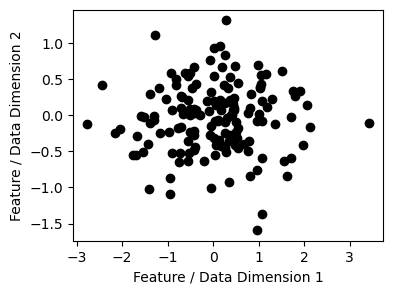

In [24]:
plt.figure()
plt.plot(x,y,'ko')
plt.xlabel("Feature / Data Dimension 1")
plt.ylabel("Feature / Data Dimension 2")
plt.show()

Now we generate a second data cloud (ellipse), that is also rotated:

In [25]:
# Random ellipse 2 centered at (1,-2)
x2 = np.random.randn(nS) + 1
y2 = 0.2*np.random.randn(nS) - 2

# Rotate ellipse 2 by theta
theta = np.pi/4
A = np.zeros((2,2))
A[0,0] = np.cos(theta)
A[0,1] = -np.sin(theta)
A[1,0] = np.sin(theta)
A[1,1] = np.cos(theta)

# Final rotated ellipse
x3 = A[0,0]*x2 + A[0,1]*y2
y3 = A[1,0]*x2 + A[1,1]*y2

Now, shown below, we have generate data from two distinct Gaussian distributions. 

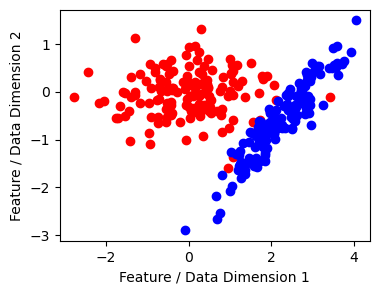

In [26]:
plt.figure()
plt.plot(x,y,'ro')
plt.plot(x3,y3,'bo')
plt.xlabel("Feature / Data Dimension 1")
plt.ylabel("Feature / Data Dimension 2")
plt.show()

### Combine data

In this case, we have ground truth data to check the k-means clustering against. Note that in general, this is not the case. 

In [27]:

# Synthetic Cluster
X1 = np.column_stack((x3,y3))  # Cluster 1 (blue)
X2 = np.column_stack((x,y))    # Cluster 2 (red)

# Merge to final synthetic dataset
Y = np.concatenate((X1,X2))                      # data vectors (x1 and x2 values)
Z = np.concatenate((np.ones(nS),2*np.ones(nS))) # labels (which we know because this dataset is synthetic)


## Example B.1: K-means Clustering with Lloyd's algorithm


For Lloyd algorithm, the user guesses the number of clusters and the initial cluster means and then the algorithm proceeds to update them in an iterative fashion. k-means is sensitive to the initial guess and many modern versions of the algorithm also provide principled strategies for initialization.

Below an illustration of the k-means iteration procedure based upon Lloyd’s algorithm. Two clusters are sought so that k = 2. The initial guesses (black circles in panel (a)) are used to initially label all the data according to their distance from each initial guess for the mean. The means are then updated by computing the means of the newly labeled data. This two-stage heuristic converges after approximately four iterations.

Based on the code below, discuss the following questions: 
1) Which variable stores the (center coordinates of the cluster)?
2) What are the initial guesses for cluster center?
3) How are the labels realized in the code (and via which variables)?
4) Do the results change, when you change the number of iterations?


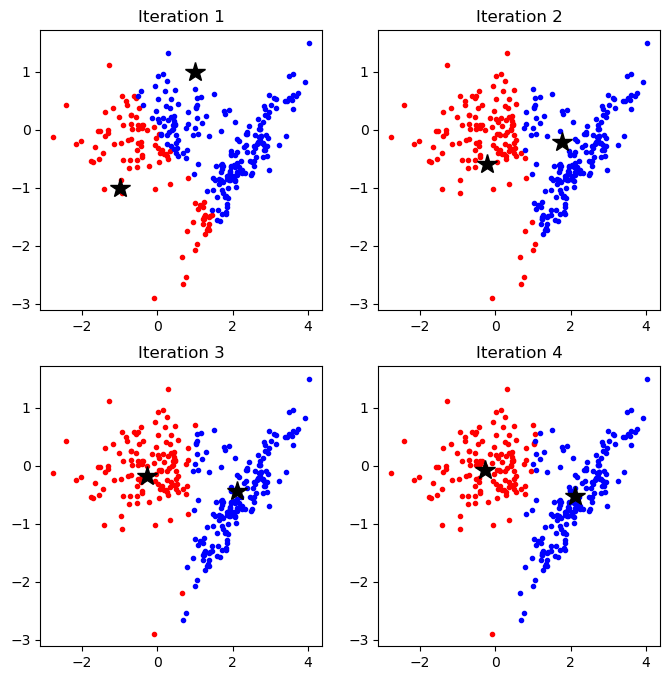

In [28]:
# Intitial guess: 2 cluster g1 and g2
g1 = np.array([-1, -1])   # Initial guess for k-mean for first cluster
g2 = np.array([1, 1])    # Initial guess for k-mean for second cluster

# Setting number of iterations
numIt = 4

# Preparing the plot
plt.rcParams['figure.figsize'] = [8, 8]
fig,axs = plt.subplots(int(np.ceil(numIt)/2),2)
axs = axs.reshape(-1)

# Iterative, heuristic Lloyd algorithm
for j in range(numIt):       # heuristic iterations
    class1 = np.zeros((1,2))
    class2 = np.zeros((1,2))
    for jj in range(Y.shape[0]):  # processing all training data
        d1 = np.linalg.norm(g1-Y[jj,:],ord=2) # distance to first k-mean
        d2 = np.linalg.norm(g2-Y[jj,:],ord=2) # distance to second k-mean
        
        # sort current point into cluster 1 or 2, depending on distance
        if d1<d2:
            class1 = np.append(class1,Y[jj,:].reshape((1,2)),axis=0)
        else:
            class2 = np.append(class2,Y[jj,:].reshape((1,2)),axis=0)
    
    class1 = np.delete(class1, (0), axis=0) # remove zeros used to initialize
    class2 = np.delete(class2, (0), axis=0)    
    
    # plot sorted points with different color per cluster into current subplot
    axs[j].plot(class1[:,0],class1[:,1],'ro',ms=3)
    axs[j].plot(class2[:,0],class2[:,1],'bo',ms=3)
    axs[j].plot(g1[0],g1[1],'k*',ms=15)
    axs[j].plot(g2[0],g2[1],'k*',ms=15)
    axs[j].title.set_text('Iteration ' + str(j+1))
    
    # Updating the k-means
    g1 = np.array([np.mean(class1[:,0]),np.mean(class1[:,1])])
    g2 = np.array([np.mean(class2[:,0]),np.mean(class2[:,1])])    
    
plt.show()


### Track the convergence of the algorithm

Use the code from above and expand the code to calculate the within-cluster sum of squares for each iteration.

In [29]:

### ADD YOUR CODE HERE








Now make a plot of the sum of squares per number of iteration. At which iteration does the algorithm converge?

In [30]:

### ADD YOUR CODE HERE





## Example B.2: k-means clustering with sklearn & it's properties

The package  `sklearn.cluster` provides a `k-means` **class** that can solve the problem using either Lloyd’s or Elkan’s algorithm. Inspect the code below how to use it.


In [31]:
from sklearn.cluster import KMeans

# kmeans code
myKmeans = KMeans(n_clusters=2, random_state=0, algorithm="lloyd")  # Compute k-means clustering with Lloyd's algorithm.
labels   = myKmeans.fit_predict(Y)   # cluster assignments for each point
cntrs    = myKmeans.cluster_centers_

myKmeans2 = KMeans(n_clusters=2, random_state=0, algorithm="elkan")  # Compute k-means clustering with Elkan algorithm.
labels2   = myKmeans2.fit_predict(Y)   # cluster assignments for each point
cntrs2    = myKmeans2.cluster_centers_


Now let's look at the difference between sklearn k-means and Loyd's algorithm a after 4 iterations (results from previous section). 

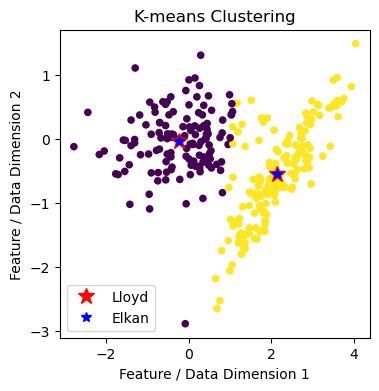

In [32]:
plt.rcParams['figure.figsize'] = [4, 4]

# data points & labels from Lloyds algorithm
plt.scatter(Y[:,0], Y[:,1], c=labels, s=20, cmap='viridis')  # color by cluster

# centers from Lloyds algorithm: big circles
plt.plot(cntrs[0,0],cntrs[0,1],'r*',ms=12,label='Lloyd')
plt.plot(cntrs[1,0],cntrs[1,1],'r*',ms=12)

# result from previous section: big circles
#plt.plot(g1[0],g1[1],'r*',ms=12,label='Lloyd')
#plt.plot(g2[0],g2[1],'r*',ms=12)

# centers from Elkans algorithm: small stars
plt.plot(cntrs2[0,0],cntrs2[0,1],'b*',ms=7,label='Elkan')
plt.plot(cntrs2[1,0],cntrs2[1,1],'b*',ms=7)

plt.title("K-means Clustering")
plt.xlabel("Feature / Data Dimension 1")
plt.ylabel("Feature / Data Dimension 2")
plt.legend()
plt.show()


### Tutorial: Apply kmeans class attibutes to answer the following questions

For that, find more details on attibutes of the class `sklearn.cluster.KMeans` on the document pages: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans

- How do you alter number of clusters (e.g. from 2 to 3)?
- How do you retrieve the labels, and what are they?
- How many iterations did the algorithm run?
- How can you retrieve sum of squared distances?
- What information is stored in `n_features_in_`?
- How accurate is the algorithm ? (compeare kmean labels with labels in Z containing synthetic cluster labels)

In [33]:

### ADD YOUR CODE BELOW


#How do you alter number of clusters (e.g. from 2 to 3). ?


#Which algorithm is used, if not specified?


#How do you retrieve the labels, and what are they?


#How many iterations did the algorithm run?


#How can you retrieve sum of squared distances?


#What information is stored in `n_features_in_`?: Number of features seen during fit.


#How accurate is the algorithm ?



### Tutorial: kmeans with different k

Calculate a new kmeans clustering on the training dateaset (`Y`) with the sklearn function for different number of clusters. Then plot the results (color points by cluster to visualize the cluster). Add also the resulting cluster centers. See how the k-value significantly impacts your results.


In [34]:

### ADD YOUR CODE HERE


## Hierarchical Clustering (Dendrogram) 

Dendrogram approach or hierarchical clustering uses a different idea, that might be able to produce a better accuracy for our test dataset.

Here we use the sklearn Agglomerative Clustering algorithm.
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html#sklearn.cluster.AgglomerativeClustering

As we can see, this clustering method is more accurate.

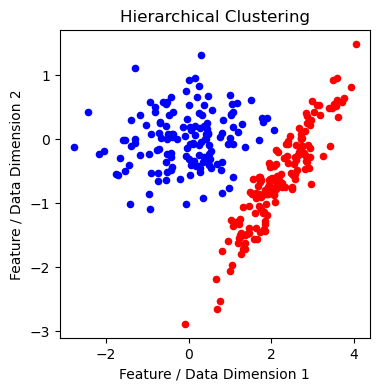

In [36]:

# Hierarchical clustering
from sklearn.cluster import AgglomerativeClustering
myHcluster = AgglomerativeClustering(n_clusters=2).fit(Y)
HClabels = myHcluster.labels_

# plot results of hierarchical clustering
HCmask = myHcluster.labels_ == 0  # mask for samples with resulting first cluster
plt.scatter(Y[HCmask,0],Y[HCmask,1],s=20,c='r')
plt.scatter(Y[~HCmask,0],Y[~HCmask,1],s=20,c='b')
plt.title("Hierarchical Clustering")
plt.xlabel("Feature / Data Dimension 1")
plt.ylabel("Feature / Data Dimension 2")
plt.show()


---
# Exercise B

1. We want to cluster the PCA/SVD output for the cat and dog images from above. What do you think, whould we use the W (=V) matrix (features/scores) or the T (=S*V) matrix (loadings) for that? And how many clusters would we want to retrieve? Justify your choices.

2. We want to only include the first three components for this (as these explain most of the signal and important features). To do that, how many  dimensions must our clustering consider (note above we had 2 dimensions)? Do you have to slice the rows or colums in the PCA matrix (your answer for question 1) for that?

3. Now let's cluster the output of the dog and cat PCA/SVD and see if we can isolate cats and dogs this way! Let's do this with hierarchical clustering. After clustering, quantify the percentage of cats/dogs images that were labeled correctly, when comparing with the known cat and dog labels (first 80 columns are dogs, last 80 columns are cats). Visualize correct and incorrect labels in some form. Discuss the quality of the outcome.


---
# C. PCA & Clustering of Sea Surface Temperatures



We have seen above that we can calculate SVD/PCA from multiple images. If the images are part of a time series, as very common in Earth Sciences, this allows us to decompose into spatial and temporal patterns at the same time. This works exactly like Empirical Orthogonal Functions (EOFs) in atmospheric sciences.

For this, wee will work again with the global Sea Surface Temperature (SST) data from the IPSL-CM4_v1 (2003) climate model provided by the Institut Pierre Simon Laplace, Paris, France, which was provided for the IPCC Fourth Assessment experiments. 

This dataset comprises monthly maps spanning two years, with a resolution of approximately 2 degrees. 


In [40]:
from netCDF4 import Dataset
data = Dataset('./tos_O1_2001-2002.nc')
lat = data.variables['lat'][:].data
lon = data.variables['lon'][:].data
time = data.variables['time'][:].data
tos = data.variables['tos'][:].data
tos = tos -  273.15; # convert unit to Celcius
landmask = tos[1,:,:]>=1e20  # get land mask, where no data values exist: True = land, False = ocean
tos[tos>=1e20] = 0   # set missing values to 0
data.close()

In [41]:
tos.shape, landmask.shape

((24, 170, 180), (170, 180))

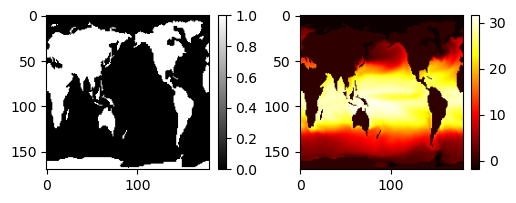

In [42]:

# plot land mask and first time step in the map
fig, ax = plt.subplots(1,2, figsize=[6,2])

im0 = ax[0].imshow(np.flipud(landmask), cmap="gray")      # True=white, False=black
im1 = ax[1].imshow(np.flipud(tos[1,:,:]),cmap = 'hot')

fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.show()


Now we want to conduct a SVD/PCA decomposition of the spatio-temporal TOS dataset, hence, we want to include all 24 maps measured over 2 years and analyze dominant spatial and temporal patterns in the data. For that we have to reshape our `tos` 3D-array into a `X` 2D-array that contains each map reshaped into a vector on one dimension, and time on the other dimension.

In [43]:
# Reshape tos data into big data matrix X
lenLon, lenLat = len(lon), len(lat)
Xglob = tos.reshape((24,lenLon*lenLat))
Xglob = np.transpose(Xglob)
Xglob.shape

(30600, 24)

Before conducting the SVD, we should also mask out the land areas, since they do not contain any data. We can apply the same mask over every column in X.

In [44]:
# Landmask as column vector
landmask_vec = landmask.reshape(lenLon*lenLat)
landmask_vec.shape

(30600,)

In [45]:
# Final Data Matrix X
X = Xglob[~landmask_vec,:] 
X.shape

(21090, 24)

In [46]:
# Center the data matrix to retrieve PCA equivalent results from the SVD
# > Compute mean of each column...
# > subtracting broadcasts across all rows...
X_centered = X - X.mean(axis=0)
X = X_centered

This is our **final data matrix X**, which we can use for unsupervised machine learning approaches.

But, before we beginn, let's demonstrate how you can revert the reshaping and masking for each column in the data matrix, allowing you to plot the results in a map later. This works as in the following example:

In [47]:
# Generate empty matrix of global size
Xnew = np.zeros(Xglob.shape)

# Unmasking: Fill only ocean areas with data values from the earlier masked X matrix
Xnew[~landmask_vec,:] = X

# Extract and reshape any column in the unmasked data matrix
tos1 = Xnew[:,0].reshape((lenLat,lenLon))
print(tos1.shape)

(170, 180)


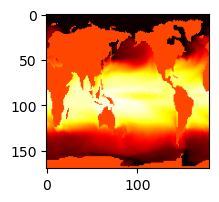

In [48]:
# Plot the to make sure this worked out
plt.figure(figsize=[3,2])
img = plt.imshow(np.flipud(tos1),cmap = 'hot')

The fact, that we see the continents as expected (our no-data pixel), means our reshaping works as planned.


--- 
# Exercise C

1. Conduct a PCA via SVD with the reshaped and land-masked matrix X. This allows us to extract spatial and temporal pattern in the data at the same time. Make plots of:

    - The normalized cumulative singular values as well as the singular values in units of percentage of the signal (total of the values).
    - Make plots of the first 4 or 6 features (spatial components).
    - The first loadings are basically time series, plot them as such (instead of the histogram we did above). The n-th loading (temporal component) belongs to the n-th feature (spatial component).
    - Plot a time series of global mean SST (of Xglob) for comparison with the loadings.

2. Thorougly discuss the results of the SVD/PCA. What do you find?

3. Attempt a clustering of the first 4-6 components. This time you want to cluster spatial features, so you should use the first 4-6 columns of the U matrix. What do you think is the ideal number of dimensions and clusters to include (there is no correct answer here). Plot a map of the cluster labels. Discuss the cluster results. Can you make a connection to the El Nino 3.4 Index? If needed, use internet resources to get a better idea what we can conclude from the clustered TOS dataset (sea surface temperature values).


Note: If we perform an SVD with a transposed `X` matrix, temporal and spatial patterns are the same, but switched between right and left singular vectors.